In [1]:
import numpy as np
import pandas as pd
import h5py
import btrack
import os

import matplotlib.pyplot as plt
import seaborn as sns

from btrack.dataio import HDF5FileHandler

In [8]:
print(btrack.__version__)

0.4.6


In [19]:
##### Original tracks 
# max_lost = 5, prob_not_assign = 0.1, dist_thresh = 40, tracker.max_search_radius = 50
# fpath = "/nfs/turbo/umms-indikar/Ram/projects/reprogramming/Image_analysis/tracking/tracks/01_control_B2.h5"
# fpath = "/nfs/turbo/umms-indikar/Ram/projects/reprogramming/Image_analysis/tracking/tracks/01_control_C2.npy.h5" ### 0 mother cells, 98.6% tracks are 1 frame
# fpath = "/nfs/turbo/umms-indikar/Ram/projects/reprogramming/Image_analysis/tracking/tracks/02_control_C2.npy.h5" ### 4 mother cells, 98.6% tracks are 1 frame
# fpath = "/nfs/turbo/umms-indikar/Ram/projects/reprogramming/Image_analysis/tracking/tracks/02_control_D2.npy.h5" ### 0 mother cells
# fpath = "/nfs/turbo/umms-indikar/Ram/projects/reprogramming/Image_analysis/tracking/tracks/02_hybrid_C4.npy.h5" ### 31 mother cells
# fpath = "/nfs/turbo/umms-indikar/Ram/projects/reprogramming/Image_analysis/tracking/tracks/01_mmMYOD1_D3.npy.h5"
# fpath = "/nfs/turbo/umms-indikar/Ram/projects/reprogramming/Image_analysis/tracking/tracks/02_mmMYOD1_D4.npy.h5" ### 1 mother cell


##### New tracks (Parameter tuning)
# changed max_lost to 2, prob_not_assign to 0.01, dist_thresh to 60, and tracker.max_search_radius to 30
# fpath = "/scratch/indikar_root/indikar1/jrcwycy/HYB/btrack/tracks_test/02_control_C2.h5" ### 11 mother cells (increase from 4), 98.6% tracks are 1 frame
fpath = "/scratch/indikar_root/indikar1/jrcwycy/HYB/btrack/tracks_test/01_control_C2.h5" ### 0 mother cells, 98.6% tracks are 1 frame

with HDF5FileHandler(fpath, "r") as reader:
    tracks = reader.tracks


track_data = []
for track in tracks:
    track_data.append(track.to_dict())
    
df = pd.DataFrame(track_data)
print(df.shape)
print(df['ID'].nunique())

# find nested cols
nested_cols = [
    col for col in df.columns 
    if isinstance(df[col].iloc[0], (list, tuple, np.ndarray))
]

df = df.explode(nested_cols).reset_index(drop=True)
df = df.infer_objects()

print(df.shape)
print(df['ID'].nunique())


# compute track lengths
df['track_length'] = df.groupby('ID')['t'].transform('count')

df = df.sort_values(by=['ID', 't'])

df.head()

[INFO][2026/07/16 12:58:17 PM] Opening HDF file: /scratch/indikar_root/indikar1/jrcwycy/HYB/btrack/tracks_test/01_control_C2.h5...
[INFO][2026/07/16 12:58:17 PM] Loading tracks/obj_type_1
[INFO][2026/07/16 12:58:17 PM] Loading objects/obj_type_1 (39967, 5) (39967 filtered: None)
[INFO][2026/07/16 12:58:18 PM] Closing HDF file: /scratch/indikar_root/indikar1/jrcwycy/HYB/btrack/tracks_test/01_control_C2.h5


(24604, 16)
24604
(40126, 16)
24604


,ID,t,x,y,z,parent,root,state,generation,dummy,minor_axis_length,major_axis_length,area,eccentricity,orientation,solidity,track_length
9158,1,0,1775.038452,1588.376953,0.0,1,1,5,0,False,8.810440,18.842325,130.0,0.883947,0.566947,0.935252,1
12750,2,0,973.022095,1548.486206,0.0,2,2,5,0,False,12.120953,18.993742,181.0,0.769908,1.045085,0.973118,1
14131,3,0,1531.032837,1548.713135,0.0,3,3,5,0,False,9.348162,16.715530,122.0,0.828999,-1.175973,0.931298,1
14132,4,0,1255.821899,1556.876709,0.0,4,4,5,0,False,9.503513,19.609922,146.0,0.874720,0.822228,0.960526,1
14133,5,0,1448.301514,1563.191162,0.0,5,5,5,0,False,9.824015,17.694544,136.0,0.831717,-0.823352,0.931507,1


In [3]:
df['track_length'].describe()

count    94458.000000
mean        40.940100
std         55.257104
min          1.000000
25%          1.000000
50%          1.000000
75%         88.000000
max        137.000000
Name: track_length, dtype: float64

In [20]:
length_thresh = 5

df_filt = df[df['track_length'] >= length_thresh].copy()

total_frames = df['t'].nunique()
n_total_tracks = df['ID'].nunique()
n_filt_tracks = df_filt['ID'].nunique()

print(f'Total tracks: {n_total_tracks}')
print(f'Total frames: {total_frames}')
print(f'Total tracks >= {length_thresh} frames: {n_filt_tracks}')
print(f'{((n_total_tracks - n_filt_tracks) / n_total_tracks) * 100:.1f}% of tracks are less than {length_thresh} frames\n')

print(df_filt.shape)
df_filt.head()

Total tracks: 24604
Total frames: 67
Total tracks >= 5 frames: 306
98.8% of tracks are less than 5 frames

(15772, 17)


,ID,t,x,y,z,parent,root,state,generation,dummy,minor_axis_length,major_axis_length,area,eccentricity,orientation,solidity,track_length
13247,98,0,608.037292,1161.671631,0.0,98,98,5,0,False,9.363139,18.369810,134.0,0.860351,1.385075,0.937063,67
13248,98,1,610.862305,1163.246338,0.0,98,98,5,0,False,9.829803,18.000374,138.0,0.837727,1.423521,0.965035,67
13249,98,2,613.530640,1163.911621,0.0,98,98,5,0,False,10.200546,18.511971,147.0,0.834489,1.491146,0.896341,67
13250,98,3,616.268982,1163.517212,0.0,98,98,5,0,False,10.314283,17.945845,145.0,0.818333,1.563721,0.947712,67
13251,98,4,617.526001,1162.506470,0.0,98,98,5,0,False,10.245037,19.157969,154.0,0.845000,-1.495574,0.933333,67


In [151]:
print(df_filt['y'].max())
print(df_filt['x'].max())

1237.8677978515625
1631.227294921875


## Sample tracks

Track ID: 18841
	path length: 88


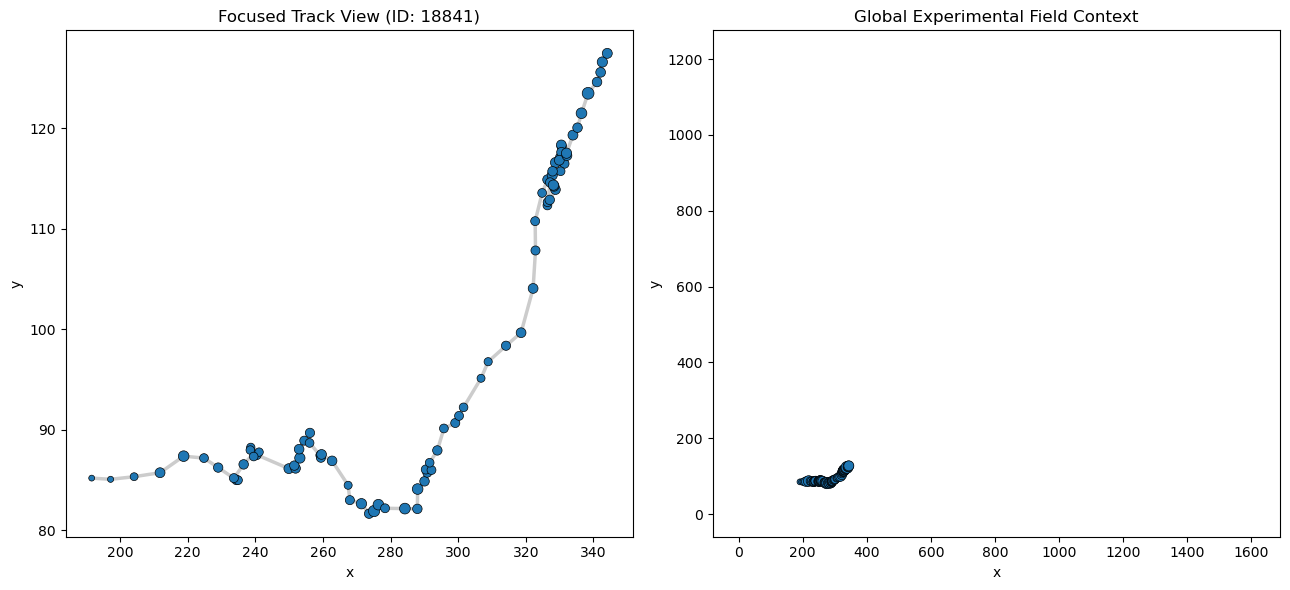

In [7]:
sample_cell = np.random.choice(df_filt['ID'].unique(), 1)[0]
print(f'Track ID: {sample_cell}')

path = df_filt[df_filt['ID'] == sample_cell].reset_index()
path = path.sort_values(by='t')
print(f'\tpath length: {len(path)}')

# 2. Pre-calculate global axis limits based on the complete dataset
x_min, x_max = df_filt['x'].min(), df_filt['x'].max()
y_min, y_max = df_filt['y'].min(), df_filt['y'].max()

# Add a tiny padding margin (e.g., 5%) so points right on the edge don't get clipped
x_pad = (x_max - x_min) * 0.05
y_pad = (y_max - y_min) * 0.05

# 3. Initialize a 1x2 Subplot Layout
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6), dpi=100)

# --- SUBPLOT 1: Local / Auto-focused view ---
sns.scatterplot(
    data=path,
    x='x',
    y='y',
    size='area',
    ec='k',
    legend=False,
    ax=ax1
)

ax1.plot(
    path['x'],
    path['y'],
    lw=2.5,
    alpha=0.4,
    color='gray',
    zorder=0
)
ax1.set_title(f'Focused Track View (ID: {sample_cell})')

# --- SUBPLOT 2: Global view bounded by full dataset scale ---
sns.scatterplot(
    data=path,
    x='x',
    y='y',
    size='area',
    ec='k',
    legend=False,
    ax=ax2
)

ax2.plot(
    path['x'],
    path['y'],
    lw=2.5,
    alpha=0.4,
    color='gray',
    zorder=0
)

# Apply global scale limits
ax2.set_xlim(x_min - x_pad, x_max + x_pad)
ax2.set_ylim(y_min - y_pad, y_max + y_pad)
ax2.set_title('Global Experimental Field Context')

plt.tight_layout()
plt.show()

In [21]:
parent_counts = df_filt.groupby('parent')['ID'].nunique()
dividing_parents = parent_counts[parent_counts == 3].index.tolist()
print(len(dividing_parents))

dividing_parents

0


[]

(178, 17)
Mother 14959 end frame: 54
	Total track length = 16

Daughter 21695 start frame: 56
	Distance from Mother centroid: 48.99 px
	Total track length = 81

Daughter 21696 start frame: 56
	Distance from Mother centroid: 51.07 px
	Total track length = 81



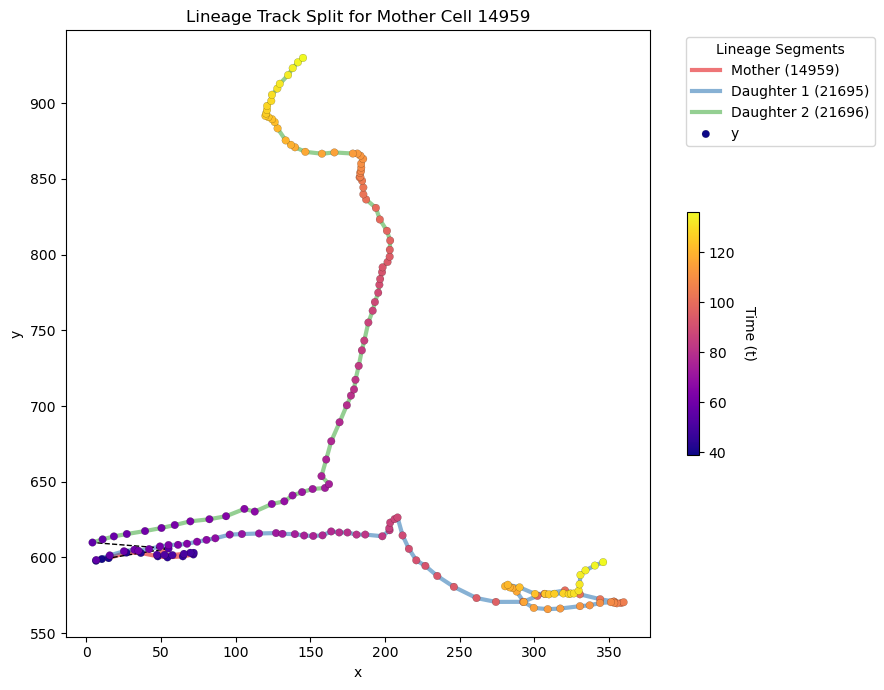

(95, 17)
Mother 30200 end frame: 100
	Total track length = 24

Daughter 40229 start frame: 101
	Distance from Mother centroid: 25.27 px
	Total track length = 36

Daughter 40656 start frame: 102
	Distance from Mother centroid: 40.45 px
	Total track length = 35



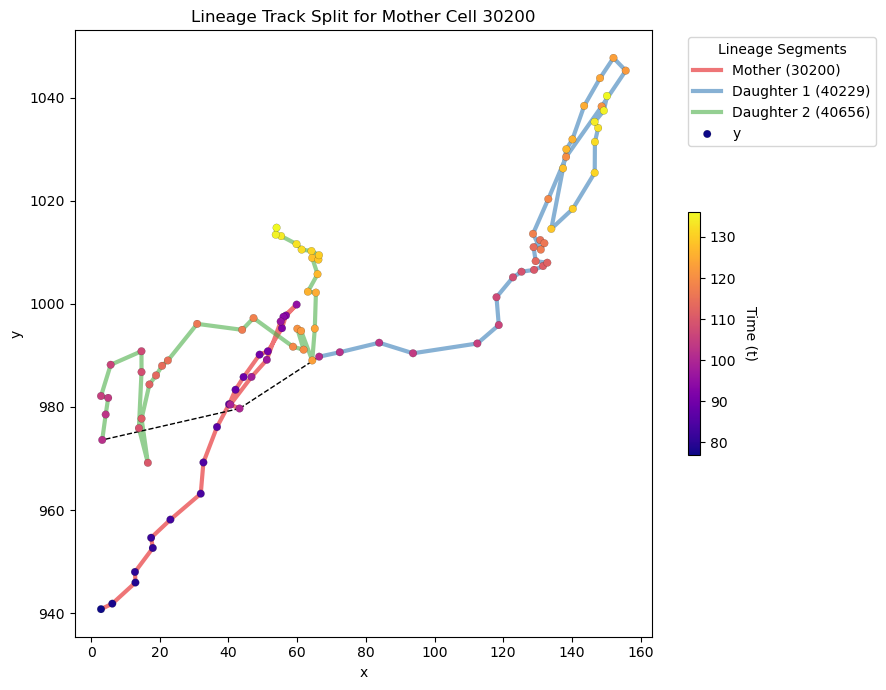

(83, 17)
Mother 32185 end frame: 103
	Total track length = 22

Daughter 41475 start frame: 104
	Distance from Mother centroid: 25.59 px
	Total track length = 33

Daughter 41911 start frame: 105
	Distance from Mother centroid: 43.38 px
	Total track length = 28



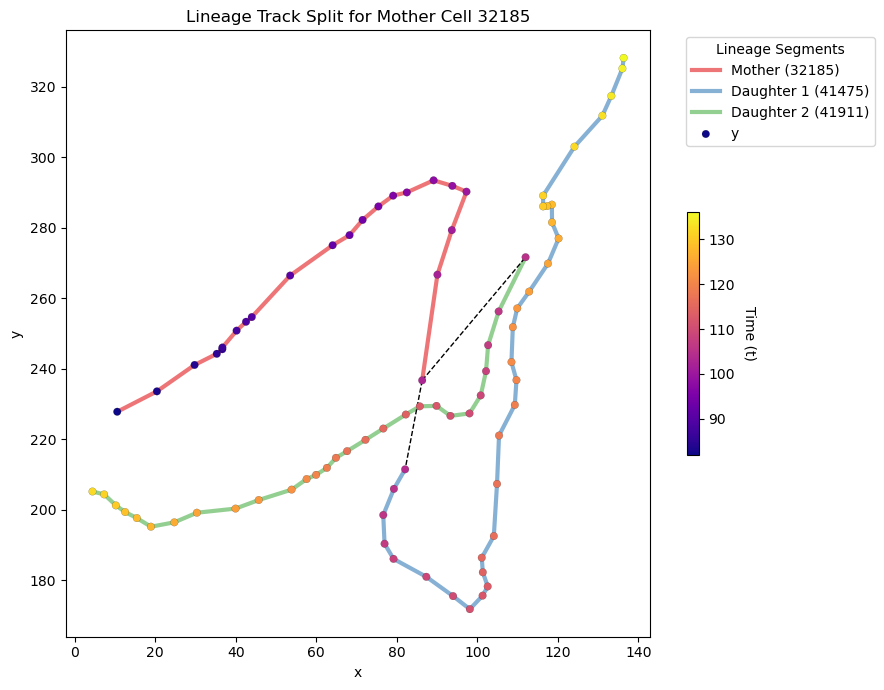

(107, 17)
Mother 30982 end frame: 86
	Total track length = 8

Daughter 34281 start frame: 87
	Distance from Mother centroid: 8.86 px
	Total track length = 50

Daughter 34695 start frame: 88
	Distance from Mother centroid: 46.32 px
	Total track length = 49



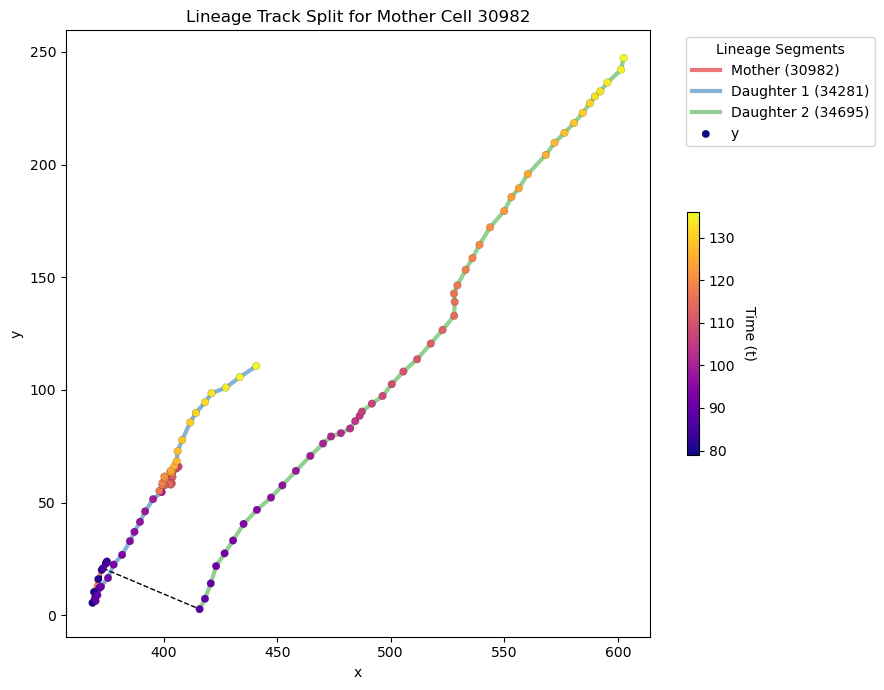

(80, 17)
Mother 35940 end frame: 101
	Total track length = 11

Daughter 40622 start frame: 102
	Distance from Mother centroid: 9.07 px
	Total track length = 35

Daughter 41063 start frame: 103
	Distance from Mother centroid: 24.80 px
	Total track length = 34



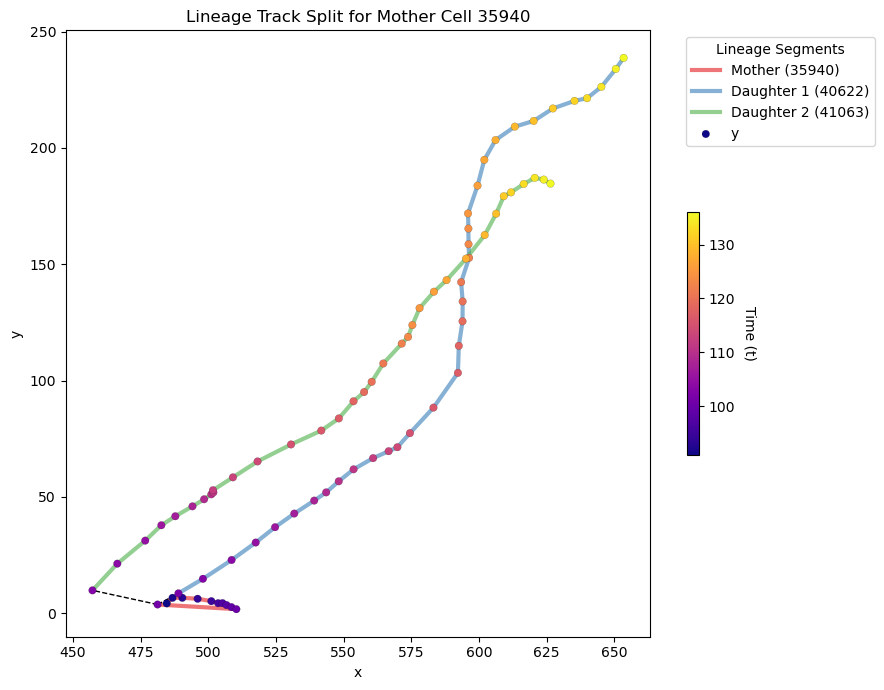

(47, 17)
Mother 39364 end frame: 127
	Total track length = 29

Daughter 52308 start frame: 128
	Distance from Mother centroid: 41.62 px
	Total track length = 9

Daughter 52310 start frame: 128
	Distance from Mother centroid: 20.26 px
	Total track length = 9



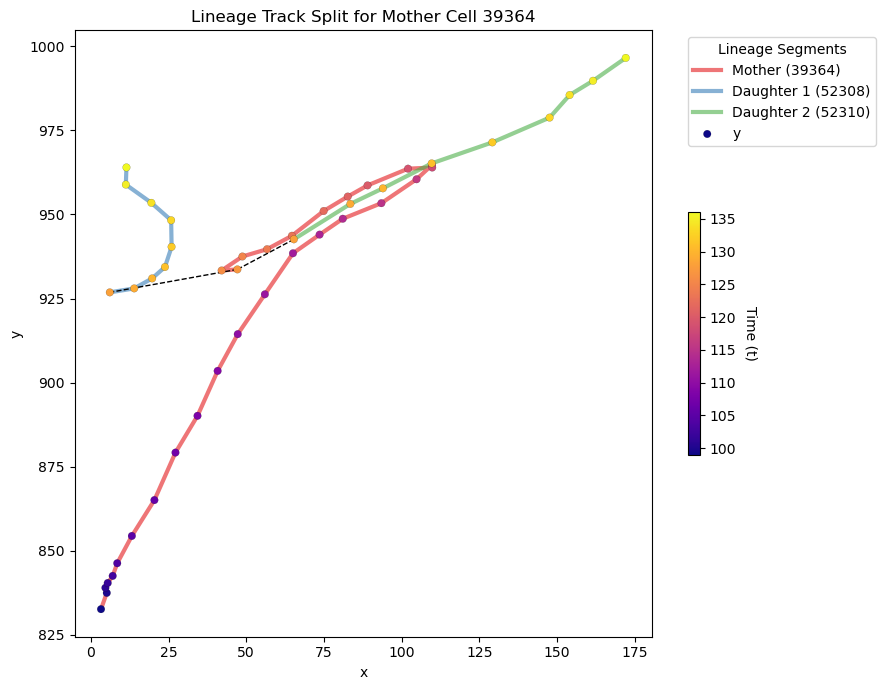

(61, 17)
Mother 36840 end frame: 119
	Total track length = 27

Daughter 48590 start frame: 120
	Distance from Mother centroid: 59.68 px
	Total track length = 17

Daughter 48593 start frame: 120
	Distance from Mother centroid: 21.46 px
	Total track length = 17



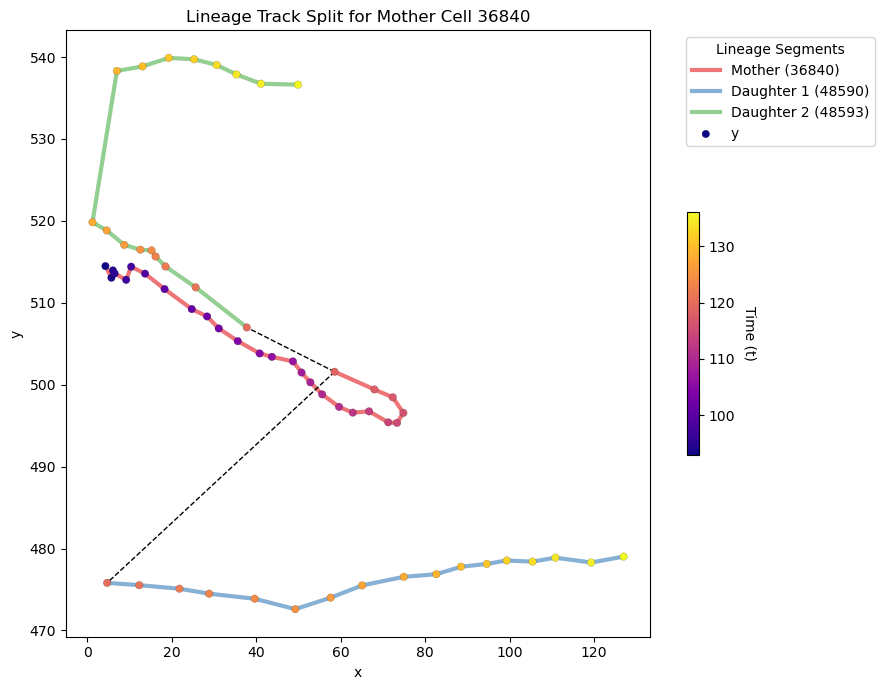

(61, 17)
Mother 33028 end frame: 124
	Total track length = 40

Daughter 50866 start frame: 125
	Distance from Mother centroid: 13.39 px
	Total track length = 9

Daughter 50867 start frame: 125
	Distance from Mother centroid: 23.92 px
	Total track length = 12



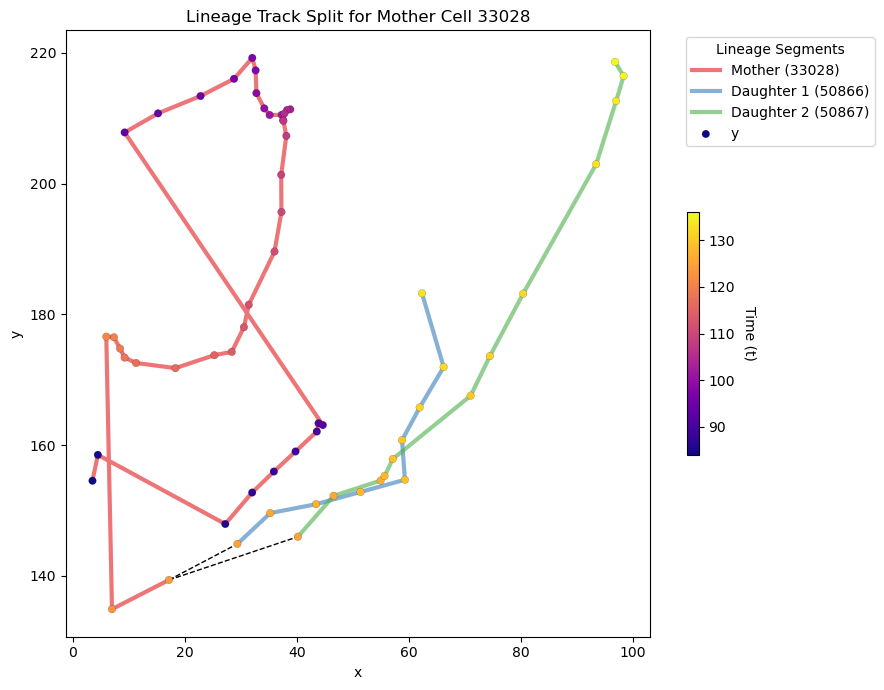

(208, 17)
Mother 4323 end frame: 54
	Total track length = 44

Daughter 21282 start frame: 55
	Distance from Mother centroid: 51.74 px
	Total track length = 82

Daughter 21289 start frame: 55
	Distance from Mother centroid: 23.57 px
	Total track length = 82



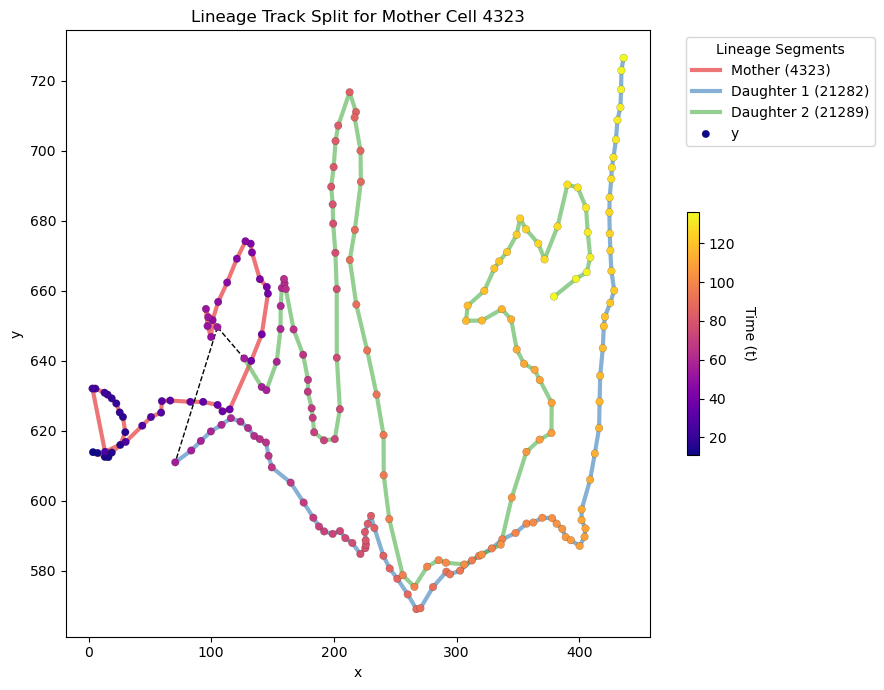

(36, 17)
Mother 43667 end frame: 127
	Total track length = 19

Daughter 52280 start frame: 128
	Distance from Mother centroid: 8.59 px
	Total track length = 9

Daughter 52752 start frame: 129
	Distance from Mother centroid: 46.07 px
	Total track length = 8



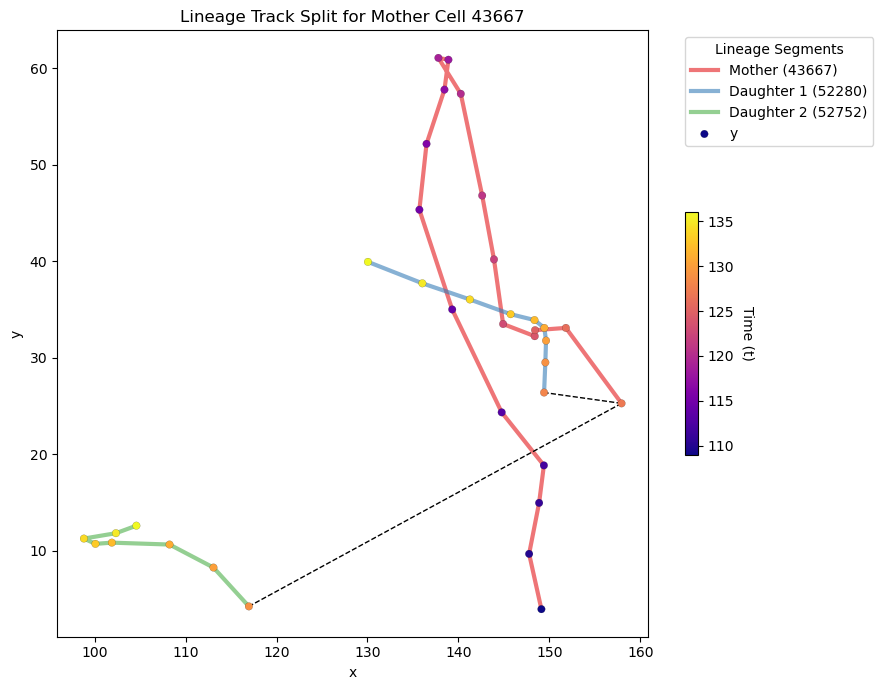

In [9]:
max_cells_to_plot = 10

if len(dividing_parents) <= max_cells_to_plot:
    parents_to_plot = dividing_parents.copy()
else:
    parents_to_plot = np.random.choice(dividing_parents, max_cells_to_plot, replace=False).tolist()


for parent_id in parents_to_plot:
    
    tmp = df_filt[df_filt['parent'] == parent_id]
    print(tmp.shape)

    daughters = tmp['ID'].unique().tolist()
    daughters.remove(parent_id)

    # end frame for parent
    end_frame = tmp[tmp['ID'] == parent_id]['t'].max()
    print(f'Mother {parent_id} end frame: {end_frame}')
    print(f"\tTotal track length = {tmp[tmp['ID'] == parent_id]['track_length'].max()}\n")


    mother_df = df_filt[df_filt['ID'] == parent_id].sort_values(by='t')
    mother_segment = mother_df[mother_df['t'] <= end_frame].copy()


    tracks_to_plot = [mother_segment]
    track_labels = [f"Mother ({parent_id})"]
    daughter_segments = []  # Keep a separate reference to daughters for connection lines


    m_last = mother_segment.iloc[-1]

    for i, d_id in enumerate(daughters):
        d_df = df_filt[df_filt['ID'] == d_id].sort_values(by='t')
        tracks_to_plot.append(d_df)
        daughter_segments.append(d_df)
        track_labels.append(f"Daughter {i+1} ({d_id})")

        if not d_df.empty:
            d_first = d_df.iloc[0]
            # Calculate Euclidean distance between the mother's end and daughter's start
            distance = np.sqrt((d_first['x'] - m_last['x'])**2 + (d_first['y'] - m_last['y'])**2)
            print(f"Daughter {d_id} start frame: {d_first['t']}\n\tDistance from Mother centroid: {distance:.2f} px")
            print(f"\tTotal track length = {d_df['track_length'].max()}\n")

    # Combine all actual pieces for the scatter dot layer
    total_scatter_df = pd.concat(tracks_to_plot).sort_values(by='t')



    # 4. Plotting Generation
    plt.figure(figsize=(9, 7), dpi=100)

    # Set distinct line colors for the 3 structural track branches
    line_palette = sns.color_palette("Set1", len(tracks_to_plot))

    for i, path in enumerate(tracks_to_plot):
        plt.plot(
            path['x'], path['y'],
            lw=3, alpha=0.6,
            color=line_palette[i],
            label=track_labels[i]
        )

    # --- Add black dashed lines connecting mother to daughters ---
    if not mother_segment.empty:
        # Get the final recorded x, y of the mother
        m_last = mother_segment.iloc[-1]

        for d_df in daughter_segments:
            if not d_df.empty:
                # Get the first recorded x, y of the daughter
                d_first = d_df.iloc[0]

                # Plot a dashed line from mother end -> daughter start
                plt.plot(
                    [m_last['x'], d_first['x']], 
                    [m_last['y'], d_first['y']], 
                    color='black', 
                    linestyle='--', 
                    linewidth=1,
                    # alpha=0.7,
                    zorder=2,  # Places them cleanly beneath the scatter dots
                    label='_nolegend_'
                )
    # -------------------------------------------------------------

    # Draw the dots over the lines, colored continuously by time frame 't'
    scatter = plt.scatter(
        data=total_scatter_df,
        x='x', y='y',
        c='t', 
        cmap='plasma',          
        s=30,
        edgecolors='k', 
        linewidths=0.1,
        zorder=3                 
    )

    # Add chronological time reference scale
    cbar = plt.colorbar(scatter, shrink=0.4)
    cbar.set_label('Time (t)', rotation=270, labelpad=15)

    # Formatting layout details
    plt.legend(title="Lineage Segments", loc="upper left", bbox_to_anchor=(1.05, 1))
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(f'Lineage Track Split for Mother Cell {parent_id}')

    plt.tight_layout()
    plt.show()


(71, 17)
Mother 38972 end frame: 104
	Total track length = 7

Daughter 41987 start frame: 105
	Distance from Mother centroid: 18.92 px
	Total track length = 32

Daughter 41994 start frame: 105
	Distance from Mother centroid: 3.77 px
	Total track length = 32



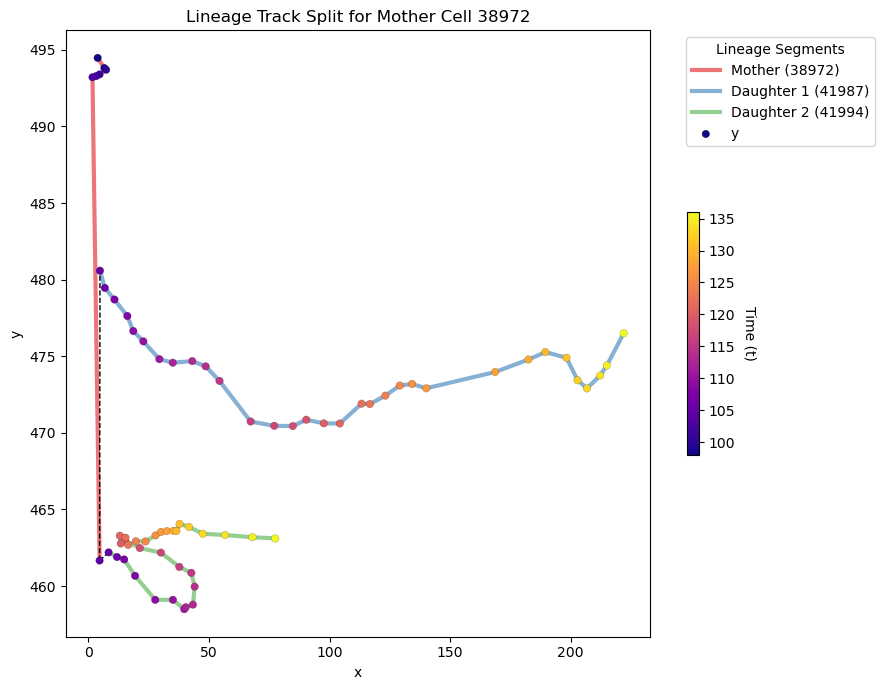

In [130]:
# parent_id = 486
# parent_id = 7551
# parent_id = 35950
parent_id = 38972

tmp = df_filt[df_filt['parent'] == parent_id]
print(tmp.shape)

daughters = tmp['ID'].unique().tolist()
daughters.remove(parent_id)


# end frame for parent
end_frame = tmp[tmp['ID'] == parent_id]['t'].max()
print(f'Mother {parent_id} end frame: {end_frame}')
print(f"\tTotal track length = {tmp[tmp['ID'] == parent_id]['track_length'].max()}\n")


mother_df = df_filt[df_filt['ID'] == parent_id].sort_values(by='t')
mother_segment = mother_df[mother_df['t'] <= end_frame].copy()


tracks_to_plot = [mother_segment]
track_labels = [f"Mother ({parent_id})"]
daughter_segments = []  # Keep a separate reference to daughters for connection lines


m_last = mother_segment.iloc[-1]

for i, d_id in enumerate(daughters):
    d_df = df_filt[df_filt['ID'] == d_id].sort_values(by='t')
    tracks_to_plot.append(d_df)
    daughter_segments.append(d_df)
    track_labels.append(f"Daughter {i+1} ({d_id})")

    if not d_df.empty:
        d_first = d_df.iloc[0]
        # Calculate Euclidean distance between the mother's end and daughter's start
        distance = np.sqrt((d_first['x'] - m_last['x'])**2 + (d_first['y'] - m_last['y'])**2)
        print(f"Daughter {d_id} start frame: {d_first['t']}\n\tDistance from Mother centroid: {distance:.2f} px")
        print(f"\tTotal track length = {d_df['track_length'].max()}\n")
    
# Combine all actual pieces for the scatter dot layer
total_scatter_df = pd.concat(tracks_to_plot).sort_values(by='t')



# 4. Plotting Generation
plt.figure(figsize=(9, 7), dpi=100)

# Set distinct line colors for the 3 structural track branches
line_palette = sns.color_palette("Set1", len(tracks_to_plot))

for i, path in enumerate(tracks_to_plot):
    plt.plot(
        path['x'], path['y'],
        lw=3, alpha=0.6,
        color=line_palette[i],
        label=track_labels[i]
    )

# --- Add black dashed lines connecting mother to daughters ---
if not mother_segment.empty:
    # Get the final recorded x, y of the mother
    m_last = mother_segment.iloc[-1]
    
    for d_df in daughter_segments:
        if not d_df.empty:
            # Get the first recorded x, y of the daughter
            d_first = d_df.iloc[0]
            
            # Plot a dashed line from mother end -> daughter start
            plt.plot(
                [m_last['x'], d_first['x']], 
                [m_last['y'], d_first['y']], 
                color='black', 
                linestyle='--', 
                linewidth=1,
                # alpha=0.7,
                zorder=2,  # Places them cleanly beneath the scatter dots
                label='_nolegend_'
            )
# -------------------------------------------------------------
    
# Draw the dots over the lines, colored continuously by time frame 't'
scatter = plt.scatter(
    data=total_scatter_df,
    x='x', y='y',
    c='t', 
    cmap='plasma',          
    s=30,
    edgecolors='k', 
    linewidths=0.1,
    zorder=3                 
)

# Add chronological time reference scale
cbar = plt.colorbar(scatter, shrink=0.4)
cbar.set_label('Time (t)', rotation=270, labelpad=15)

# Formatting layout details
plt.legend(title="Lineage Segments", loc="upper left", bbox_to_anchor=(1.05, 1))
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Lineage Track Split for Mother Cell {parent_id}')

plt.tight_layout()
plt.show()

# Columns

* ID -- track ID
* t -- time point
* x, y, z -- spatial coordinates of the tracked object
* parent -- ID of the parent track that this track split from
* root -- ID of the primary ancestor track at the top of the lineage tree
* generation -- generation number of the cell relative to the root ancestor (cell starts at 0, daughters are 1, etc.)
* state -- state of a tracklet at any given time ?
* area -- pixel count of the object's segmentation mask
* eccentricity -- measure of how elongated an object is (0 is a perfect circle, 1 is an elongated ellipse)
* solidity -- measures "bumpiness" of the objects boundary (smooth circle is 1; a cell with lots of protrusions will be lower)


In [18]:
file_list = ["/scratch/indikar_root/indikar1/shared_data/hybrid_imaging/regionprops/01_mmMYOD1_D3_props.csv"]

df_list = []

for fpath in file_list:
    basename = os.path.basename(fpath).replace(".csv", "")
    stage, condition, scene, _ = basename.split("_")
    
    df = pd.read_csv(fpath)
    df['basename'] = basename
    df['stage'] = int(stage)
    df['condition'] = condition
    df['scene'] = scene
    
    print(f"\t{basename} {df.shape=}")

    df_list.append(df)


pdf = pd.concat(df_list)
print(f"{pdf.shape=}")
pdf.head()

	01_mmMYOD1_D3_props df.shape=(33663, 49)
pdf.shape=(33663, 49)


,label,area,bbox-0,bbox-1,bbox-2,bbox-3,bbox_area,centroid-0,centroid-1,eccentricity,...,mKate_max,mKate_min,mKate_sum,time,seg_channel_idx,seg_channel_name,basename,stage,condition,scene
0,1,96.0,2007,1763,2015,1778,120.0,2010.260417,1770.062500,0.846948,...,0.211949,0.010833,18.862382,0,2,Cy5,01_mmMYOD1_D3_props,1,mmMYOD1,D3
1,2,151.0,44,1062,55,1080,198.0,49.298013,1069.940397,0.780899,...,0.211949,0.025833,30.912665,0,2,Cy5,01_mmMYOD1_D3_props,1,mmMYOD1,D3
2,3,129.0,1194,3004,1208,3018,196.0,1201.302326,3010.294574,0.638784,...,0.211949,0.002500,11.873869,0,2,Cy5,01_mmMYOD1_D3_props,1,mmMYOD1,D3
3,4,132.0,969,493,983,508,210.0,975.583333,500.257576,0.844022,...,0.024167,0.002500,1.930000,0,2,Cy5,01_mmMYOD1_D3_props,1,mmMYOD1,D3
4,5,145.0,1373,1171,1388,1185,210.0,1379.958621,1177.903448,0.773239,...,0.028333,0.002500,2.595000,0,2,Cy5,01_mmMYOD1_D3_props,1,mmMYOD1,D3


In [19]:
pdf.columns

Index(['label', 'area', 'bbox-0', 'bbox-1', 'bbox-2', 'bbox-3', 'bbox_area',
       'centroid-0', 'centroid-1', 'eccentricity', 'equivalent_diameter',
       'euler_number', 'extent', 'feret_diameter_max', 'filled_area',
       'inertia_tensor_eigvals-0', 'inertia_tensor_eigvals-1',
       'local_centroid-0', 'local_centroid-1', 'major_axis_length',
       'minor_axis_length', 'orientation', 'perimeter', 'perimeter_crofton',
       'solidity', 'Cy5_mean', 'Cy5_max', 'Cy5_min', 'centroid_x_px',
       'centroid_y_px', 'centroid_x_um', 'centroid_y_um', 'centroid_unit',
       'Cy5_sum', 'TaGFP_mean', 'TaGFP_max', 'TaGFP_min', 'TaGFP_sum',
       'mKate_mean', 'mKate_max', 'mKate_min', 'mKate_sum', 'time',
       'seg_channel_idx', 'seg_channel_name', 'basename', 'stage', 'condition',
       'scene'],
      dtype='object')

In [ ]:
# can use centroid

In [20]:
pdf['time'].nunique()

67